In [1]:
import os
import zipfile

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
root_folder_path = '/content/'
dataset_zip_path = f'{root_folder_path}drive/MyDrive/MultimodalGasData.zip'

In [4]:
if not os.path.exists(f'{root_folder_path}MultimodalGasData/'):
  with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall(root_folder_path)

In [5]:
import pandas as pd

In [6]:
dataset_root_path = '/content/'
sensor_dataset_path = os.path.join(dataset_root_path, 'Gas Sensors Measurements/Gas_Sensors_Measurements.csv')
thermal_dataset_path = os.path.join(dataset_root_path, 'Thermal Camera Images/Sample Thermal Camera Images')

In [7]:
df = pd.read_csv(sensor_dataset_path)

In [8]:
df.head()

,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas,Corresponding Image Name
0,0,555,515,377,338,666,451,416,NoGas,0_NoGas
1,1,555,516,377,339,666,451,416,NoGas,1_NoGas
2,2,556,517,376,337,666,451,416,NoGas,2_NoGas
3,3,556,516,376,336,665,451,416,NoGas,3_NoGas
4,4,556,516,376,337,665,451,416,NoGas,4_NoGas


In [9]:
df.tail()

,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas,Corresponding Image Name
6395,1595,658,445,455,414,491,321,436,Mixture,1595_Mixture
6396,1596,650,444,451,411,486,317,431,Mixture,1596_Mixture
6397,1597,630,443,446,407,474,312,429,Mixture,1597_Mixture
6398,1598,632,443,444,405,471,309,430,Mixture,1598_Mixture
6399,1599,633,442,442,402,468,306,434,Mixture,1599_Mixture


In [10]:
df.drop('Serial Number', axis=1, inplace=True)

In [11]:
df.describe()

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135
count,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,677.593438,462.024688,404.579063,399.758750,565.952031,542.473750,416.727031
std,92.913955,70.284038,55.672249,45.091353,83.133693,151.020217,76.681407
min,502.000000,337.000000,291.000000,311.000000,361.000000,220.000000,275.000000
25%,591.000000,405.000000,366.000000,366.000000,524.000000,447.000000,354.000000
50%,701.000000,486.000000,400.000000,393.000000,576.000000,576.000000,437.000000
75%,756.000000,529.000000,443.000000,426.000000,629.000000,642.000000,473.000000
max,824.000000,543.000000,596.000000,524.000000,796.000000,794.000000,589.000000


In [12]:
df.isnull().sum()

,0
MQ2,0
MQ3,0
MQ5,0
MQ6,0
MQ7,0
MQ8,0
MQ135,0
Gas,0
Corresponding Image Name,0


In [13]:
corr_mat = df.select_dtypes(include=['number']).corr()
corr_mat

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135
MQ2,1.000000,0.776312,0.644174,0.724617,0.623427,0.718423,0.748708
MQ3,0.776312,1.000000,0.647214,0.604268,0.418306,0.463899,0.904378
MQ5,0.644174,0.647214,1.000000,0.907219,0.411831,0.358977,0.846808
MQ6,0.724617,0.604268,0.907219,1.000000,0.662115,0.666487,0.746673
MQ7,0.623427,0.418306,0.411831,0.662115,1.000000,0.903144,0.324734
MQ8,0.718423,0.463899,0.358977,0.666487,0.903144,1.000000,0.361060
MQ135,0.748708,0.904378,0.846808,0.746673,0.324734,0.361060,1.000000


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

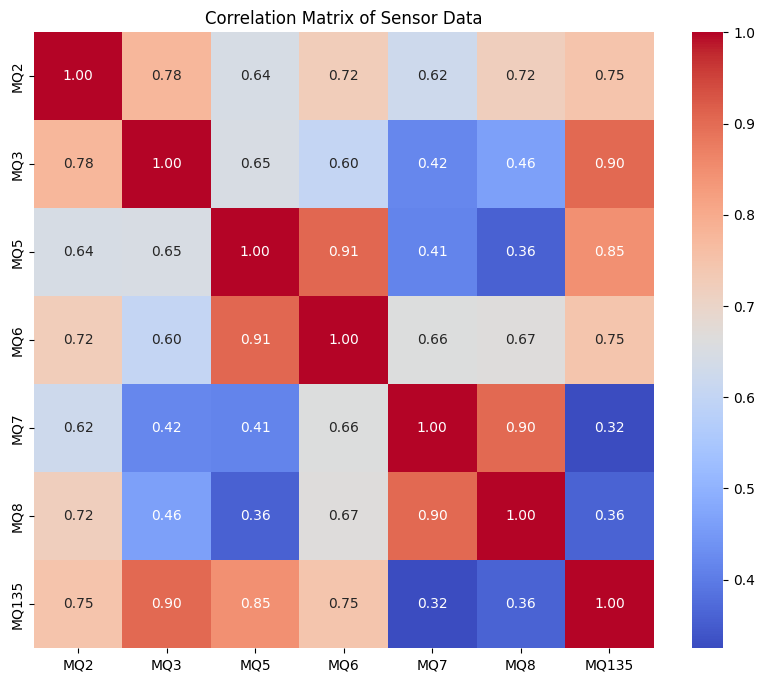

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sensor Data')
plt.show()

# Data Preprocessing

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
df.drop('Corresponding Image Name', axis=1, inplace=True)

In [18]:
df.head()

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas
0,555,515,377,338,666,451,416,NoGas
1,555,516,377,339,666,451,416,NoGas
2,556,517,376,337,666,451,416,NoGas
3,556,516,376,336,665,451,416,NoGas
4,556,516,376,337,665,451,416,NoGas


/tmp/ipython-input-1764761367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gas', data=df, palette='Set2')


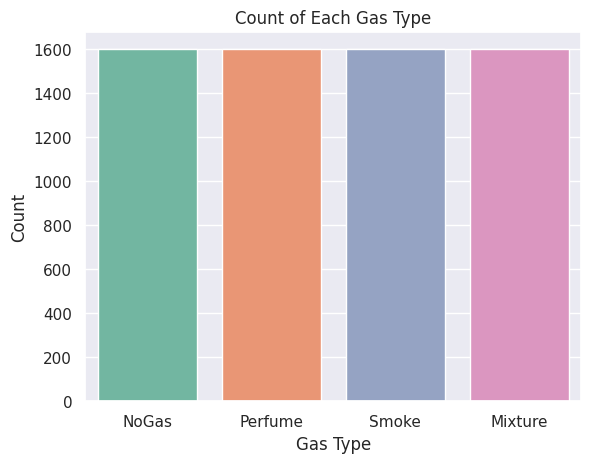

In [19]:
sns.set(style="darkgrid")
sns.countplot(x='Gas', data=df, palette='Set2')
plt.xlabel('Gas Type')
plt.ylabel('Count')
plt.title('Count of Each Gas Type')
plt.show()

In [20]:
le = LabelEncoder()
df['Gas'] = le.fit_transform(df['Gas'])

In [21]:
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

0: Mixture
1: NoGas
2: Perfume
3: Smoke


/tmp/ipython-input-1764761367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gas', data=df, palette='Set2')


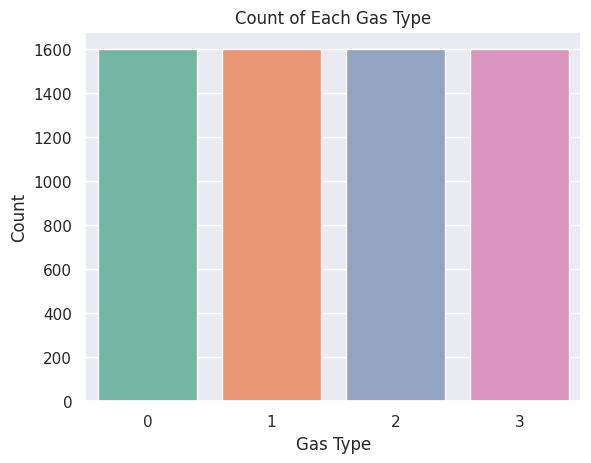

In [22]:
sns.set(style="darkgrid")
sns.countplot(x='Gas', data=df, palette='Set2')
plt.xlabel('Gas Type')
plt.ylabel('Count')
plt.title('Count of Each Gas Type')
plt.show()

In [23]:
df.head()

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas
0,555,515,377,338,666,451,416,1
1,555,516,377,339,666,451,416,1
2,556,517,376,337,666,451,416,1
3,556,516,376,336,665,451,416,1
4,556,516,376,337,665,451,416,1


In [24]:
X = df.drop('Gas', axis=1)
y = df['Gas']

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [26]:
scaler.fit(X)
X = scaler.transform(X)

In [27]:
# from keras.utils import to_categorical

# y = to_categorical(y, num_classes=4)

In [28]:
import numpy as np

# Example shapes
# X.shape = (6400, n_features)
# y.shape = (6400,) or (6400, n_classes)
n_classes = 4
samples_per_class = 1600

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

X_train, y_train = [], []
X_val, y_val = [], []
X_test, y_test = [], []

for cls in range(n_classes):
    start = cls * samples_per_class
    end = start + samples_per_class

    X_cls = X[start:end]
    y_cls = y[start:end]

    n_train = int(train_ratio * samples_per_class)
    n_val = int(val_ratio * samples_per_class)

    # Sequential split per class
    X_train.append(X_cls[:n_train])
    y_train.append(y_cls[:n_train])

    X_val.append(X_cls[n_train:n_train + n_val])
    y_val.append(y_cls[n_train:n_train + n_val])

    X_test.append(X_cls[n_train + n_val:])
    y_test.append(y_cls[n_train + n_val:])

# Concatenate all class-wise splits (keep sync between X and y)
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)
X_val = np.concatenate(X_val)
y_val = np.concatenate(y_val)
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

In [29]:
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Train: (5120, 7), (5120,)
Val:   (640, 7), (640,)
Test:  (640, 7), (640,)


# LSTM

In [30]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [31]:
n_input = 7
n_features = 7
batch_size = 64
regularizer_learning_rate = 0.01
optimizer_learning_rate = 0.001

train_gen = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=batch_size)
val_gen = TimeseriesGenerator(X_val, y_val, length=n_input, batch_size=batch_size)
test_gen = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=batch_size)

In [32]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [71]:
model = Sequential()

model.add(LSTM(128,
               input_shape=(n_input, n_features),
               kernel_regularizer=l2(regularizer_learning_rate)))

model.add(Dropout(0.2))

model.add(Dense(4, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=optimizer_learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,148 (274.02 KB)

 Trainable params: 70,148 (274.02 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
lstm_model_path = '/content/drive/MyDrive/best_lstm_model.h5'

from keras.models import load_model

pretrained_model = load_model(lstm_model_path)

model.set_weights(pretrained_model.get_weights())

model.save('best_lstm_model.keras')

In [74]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_lstm_model.keras', monitor='val_accuracy', save_best_only=True)

In [75]:
history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=100,
                    callbacks=[early_stop, checkpoint]
                    )

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9548 - loss: 0.1269 - val_accuracy: 0.8815 - val_loss: 0.3632
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9568 - loss: 0.1216 - val_accuracy: 0.8262 - val_loss: 0.4767
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9458 - loss: 0.1567 - val_accuracy: 0.8689 - val_loss: 0.4284
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9488 - loss: 0.1414 - val_accuracy: 0.9336 - val_loss: 0.2520
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9564 - loss: 0.1268 - val_accuracy: 0.8894 - val_loss: 0.3759
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9333 - loss: 0.1612 - val_accuracy: 0.8799 - val_loss: 0.4126
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9642 - loss: 0.0994 - val_accuracy: 0.8878 - val_loss: 0.3776
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9733 - loss: 0.0852 - val_accuracy: 0.9131 - 

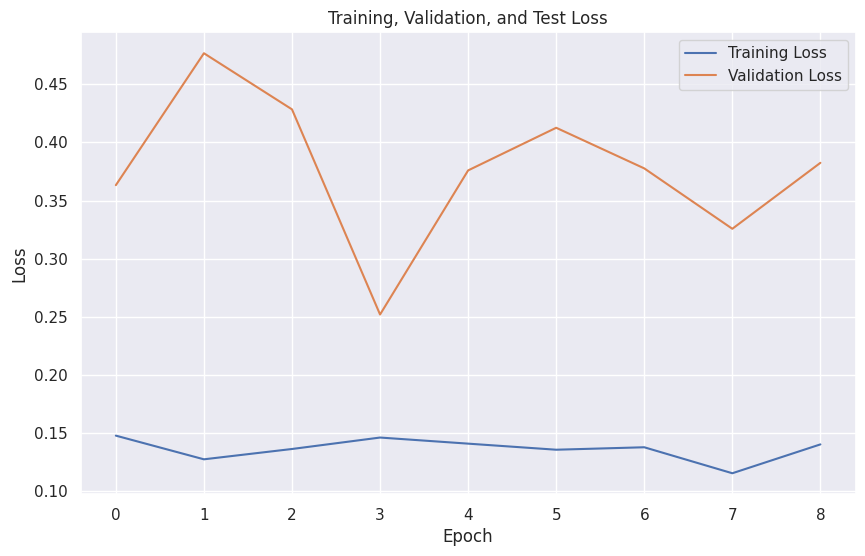

In [76]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [77]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

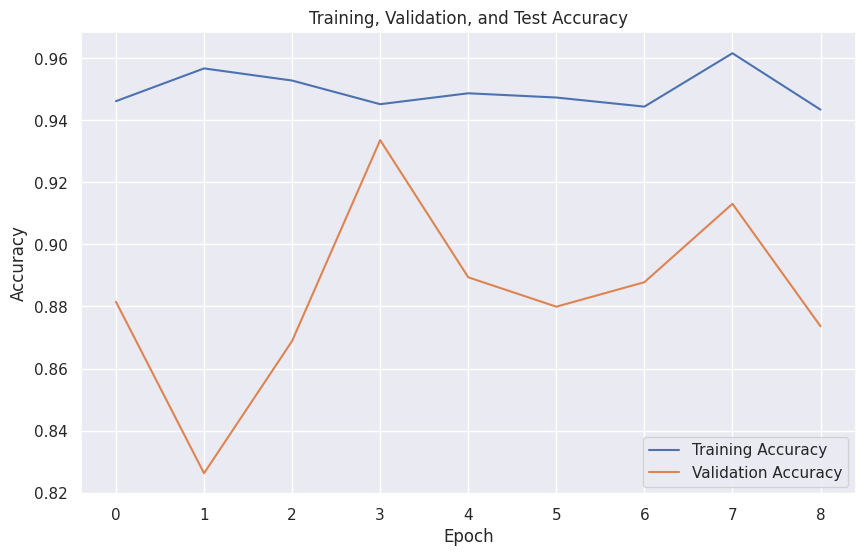

In [78]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [79]:
max(min(history.history['accuracy'], history.history['val_accuracy']))

0.9336493015289307

In [86]:
from keras.models import load_model

model = load_model('best_lstm_model.keras')

In [87]:
model.compile(optimizer=Adam(learning_rate=optimizer_learning_rate),
              loss='sparse_categorical_crossentropy')

In [88]:
train_gen = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=batch_size)
val_gen = TimeseriesGenerator(X_val, y_val, length=n_input, batch_size=batch_size)
test_gen = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=batch_size)

In [89]:
model.evaluate(train_gen)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1771


[0.11491682380437851, 0.9604928493499756]

In [90]:
model.evaluate(val_gen)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9241 - loss: 0.3010 


[0.2519634962081909, 0.9336493015289307]

In [91]:
model.evaluate(test_gen)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8881 - loss: 0.3747 


[0.2994031310081482, 0.9083728194236755]